In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [31]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns= ["region"], drop_first=False)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["bmi"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [32]:
alphas = [0.001, 0.1, 1, 2 , 4, 10, 20 ,40 ,60, 70 , 100]
mses=[]

for a in alphas:

    lasso_model = Lasso(alpha =a)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    
    mse=mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha = {a}: ",mse)
    mses.append(mse)



MSE for alpha = 0.001:  20919706.846547168
MSE for alpha = 0.1:  20919162.70082466
MSE for alpha = 1:  20914399.592187867
MSE for alpha = 2:  20909556.43340076
MSE for alpha = 4:  20901305.698311344
MSE for alpha = 10:  20888108.41490594
MSE for alpha = 20:  20903802.99485759
MSE for alpha = 40:  21066565.4958394
MSE for alpha = 60:  21325645.944429163
MSE for alpha = 70:  21517639.531209704
MSE for alpha = 100:  22331198.22527373


<Axes: >

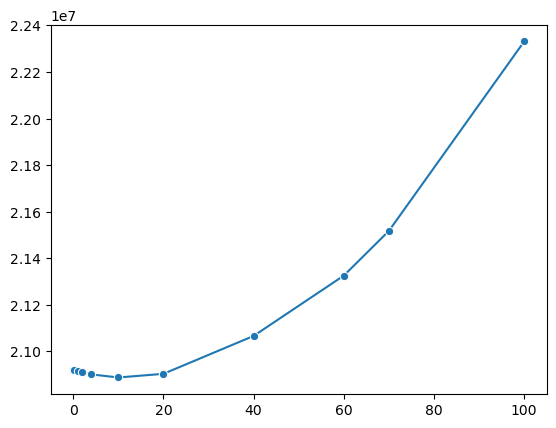

In [33]:
sns.lineplot(x= alphas, y = mses, marker="o")

# Cross_Validation

In [34]:
from sklearn.linear_model import LassoCV


In [35]:
a = [0.001, 0.1, 1, 2 , 4, 10, 20 ,40 ,60, 70 , 100]

lasso_CV_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter=1000,
    random_state=42
    
)
lasso_CV_model.fit(X_train, y_train)
print("best alpha: ", lasso_CV_model.alpha_)

y_pred = lasso_CV_model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print("mse = ", mse)

r2 = r2_score(y_test, y_pred)
print("mse= ",mse)
print("r2= ", r2)

best alpha:  0.001
mse =  20919706.846547168
mse=  20919706.846547168
r2=  0.8652503846857152
